# Calorimetry

<div>
  <center> <img height="500" src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Figures/Thermogram.png?raw=True"> </center>
</div>


<a target="_blank" href="https://colab.research.google.com/github/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Calorimetry.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Understanding Temperature Changes During Mixing

When two liquids are combined in a calorimeter to carry out a chemical reaction, the temperature does not change instantaneously even if the reaction itself is rapid. This is largely due to molecular diffusion: it takes time for the substances to fully mix and for the heat released or absorbed by the reaction ($\Delta H_\text{rxn}$) to spread throughout the solution.

In an ideal, perfectly insulated calorimeter, we would observe a flat, constant temperature before the reaction ($T_i$) and again after the reaction has completed ($T_f$). In such a case, calculating the temperature change ($\Delta T$) would be simple:  
$$
\Delta T = T_f - T_i
$$

However, real-world calorimeters are not perfect. Small amounts of heat can be lost or gained from the surroundings, leading to gradual drift in temperature both before and after the reaction. This makes it harder to pinpoint a single moment when the reaction has "fully occurred."

Since there's no single, universally accepted method for identifying this **instantaneous mixing time** ($t_\text{mix}$), we must rely on models and graphical analysis to estimate it. In this activity, you will explore two methods to predict $t_\text{mix}$:
1. $T_{.63R}$ Method
2. Equivalent areas Method


In [ ]:
# @title Overview
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.info {
    color: #0056b3;
    background-color: #d9edf7;
    border-left: 5px solid #31708f;
    padding: 0.5em;
    font-size: 1.25em; /* A little larger the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.info ul {
    margin: 0.5em 0; /* Space around the list */
}
div.info li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="info">
    <strong>Questions:</strong>
    <ul>
        <li> What physical processes might cause the temperature to drift before and after the reaction? </li>
        <li>How can we fit a thermogram? </li>
          <ul>
          <li>Can we use analytical functions can we use to fit our data? Will there be uncertainities in the fittings?</li>
          <li>How can fitting lines to the pre- and post-reaction regions help us better estimate the true temperature change?</li>
          <li>What assumptions are we making when we use line fits to model the pre- and post-reaction baselines?</li>
          </ul>
        <li>How do we calculate the instantaneous mixing time (\(t_{mix}\)) from our data?</li>
    </ul>

    <strong>Objectives:</strong>
    <ul>
        <li>Use non-linear numerical fitting techniques to fit experimental data.</li>
        <li>Use Python functions to simplify repetitive tasks.</li>
        <li>Calculate \(\Delta H_{rxn}\) using calorimetric techniques.</li>
    </ul>
</div>

In [1]:
# @title Hit the play button to import packages
%%capture
# Import standard packages
import numpy as np # Import numerical analysis
import os,sys,re # Import regex
import pandas as pd # DataFrame analysis

#Spectra fitting - scipy
from scipy import interpolate
from scipy import integrate
import scipy.optimize
from scipy import stats
from scipy.stats import skewnorm
from scipy.integrate import quad

#Sliders
import ipywidgets as widgets

# Plotting
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 16})
matplotlib.rcParams.update({'font.family': 'Sans'})
matplotlib.rcParams.update({'mathtext.fontset' : 'custom'})

import warnings
# Suppress font manager fallback warning
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

# Insert a progress bar to show the progress of the script
!jupyter nbextension enable --py widgetsnbextension
from tqdm.notebook import tqdm, tnrange, trange

%pip install lmfit
from lmfit import Model

#Quizzes and Animations
from IPython.display import display, HTML, clear_output
import time

%pip install "jupyterquiz"
from jupyterquiz import display_quiz

#Import quizzes and rotation1.json from GitHub
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-2-Calorimetry/rotation2.json
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-2-Calorimetry/t63_interactive.py
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-2-Calorimetry/equiv_interactive.py
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/Rotation-2-Calorimetry/Sample-Data/Calorimetry_SampleData.xlsx
!wget https://raw.githubusercontent.com/pmpatel-udallas/CHE-3131/main/quiz_utils.py

import quiz_utils


In [ ]:
# @title Hit the play button to link your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Part 1. Calculate $\Delta$T

Typically, in a calorimetry experiment $\Delta T$ must be determined with care for several reasons. The chemical reaction takes place in a finite volume ($\sim$120 mL for this experiment), so the temperature of the surroundings is coming to equilibrium as the reaction proceeds to completion. Thus, there may be a temporary non-uniformity in temperature while the temperature is monitored in only one location in the solution. Stirring greatly helps maintain uniformity of temperature, but in the crucial first few fractions of a second after the reactants are mixed, the instantaneous change in temperature may not be detected. But, stirring may also introduce an endothermic “leak” by imparting some frictional heat into the surroundings. Additionally, the calorimeter may not be fully insulated from its surroundings, introducing an exothermic “leak” as the temperature of the water in the Dewar flask exceeds the temperature outside the flask.

In the apparatus used for this laboratory, the Dewar flask is very well insulated but as soon as the mixture reaches a peak temperature you may see it begin to return slowly to ambient temperature. These issues do not pose an insurmountable barrier to getting the right $\Delta T$, but some interpretation of the “thermogram”, the temperature vs. time trace, is required.

<div>
  <center> <img height="400" src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Figures/SolutionCalorimeter.png?raw=True"> </center>
</div>


## 1.1 How can we interpret the thermogram?

The following interactive functions will contain a sample analysis using both methods ($T_{.63R}$ and Equivalent areas) to calculate $\Delta T$.

The $T_{.63R}$ method uses
$$T_{.63R}=T_i + (\Delta T \times 0.632)$$
where $\Delta T$ is the difference between the extrapolated pre-reaction trend and the extrapolated post-reaction trend on a vertical line at the equivalent instantaneous mixing time (**$t_{mix}$**), which intersects the thermogram at $T_{.63R}$. This analysis should be done numerically, fitting both the pre-reaction and post reaction data to a straight line.

To equivalent areas method uses
$$
\int_{t_1}^{t_{mix}} \left[ T_{\text{pre-reaction}}(t) - T(t) \right] \, dt = \int_{t_{mix}}^{t_2} \left[ T(t) - T_{\text{post-reaction}}(t) \right] \, dt
$$
where $T(t)$ represents the experimental temperature as a function of time. Before the reaction begins, we define a baseline trend $T_{\text{pre-reaction}}(t)$, and after the reaction has completed, we define a second baseline $T_{\text{post-reaction}}(t)$. Let $t_1$ be the time just before the temperature begins to rise and $t_2$ be the time after the system has stabilized. The goal is to determine at which time $t_{mix}$ between $t_1$ and $t_2$ where the areas on either side of the idealized vertical temperature jump are equal.

In [ ]:
# @title Exercise: Analyze Interactive Functions
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
<p> Analyze the interactive graphs. Think about the following for each method:
<ul>
<li> How does changing x\(_1\), x\(_2\), and x\(_3\) affect \(\Delta T\)? </li>
<li>Does your chosen \( t_{mix} \) minimize residuals or visual error between model and data?</li>
<li>How would using an analytical function help in this analysis?</li>
<li>What does your chosen \( t_{mix} \) reflect in each interactive plot below?</li>
</ul>
</p>
</div>

In [3]:
# @title Analyze this interactive graph for the $T_{.63R}$ method
# @markdown Hit the play button twice. This will get rid of the matplotlib font loading error.
%run t63_interactive.py

interactive(children=(FloatSlider(value=91.0, continuous_update=False, description='x1:', max=150.0, min=80.0,…

<Figure size 640x480 with 0 Axes>

In [ ]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation2.json','lab-2-2')

<IPython.core.display.Javascript object>

<font color=red> Answer to quiz questions are 96.07 and 0.520859

In [ ]:
# @title **Question 1**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">

    <p>What features does the interactive thermogram plot help you explore,
      and how do they relate to determining the instantaneous mixing time in a calorimetry experiment?</p>
</div>


---
**Answer goes here**

<font color=red> The interactive thermogram plot is a visual tool that helps identify the point in time when the temperature change has reached 63.2% of its total range. This is commonly used to estimate the mixing time in a calorimetry experiment. The graph displays several key features:

- <font color=red> **Raw Thermogram Curve**: Displays the measured temperature over time during the experiment.
- <font color=red> **Best-Fit Lines for Initial and Final Regions**: Linear regressions fitted to the early and late parts of the curve represent the baseline temperatures before and after the reaction. These are labeled as Ti1 and Tf1.
- <font color=red> **$T_{63R}$ Reference Line**: A dashed line representing the temperature that is 63.2% of the distance between the two baseline fits.
- <font color=red> **Movable Markers for $x_1$, $x_2$, and$x_3$**:
  - <font color=red> $x_1$: Start of the initial baseline (Creates best fit line pre-reaction)
  - <font color=red> $x_2$: Candidate value for the mixing time ($T_{63R}$)
  - <font color=red> $x_3$: Start of the final baseline (Creates best fit line post-reaction)
- <font color=red> **$\Delta T$ Line at $x_2$**: A vertical dashed line at $x_2$ showing the gap between the two baseline lines at that time. This represents the calculated $\Delta T$. The calculated temperature difference between the two fit lines at $x_2$, which helps understand the magnitude of heat change.
- <font color=red> **Difference from 63.2%**: Printed below the plot, this value quantifies how close the selected $x_2$ is to the ideal 63.2% point. The goal is to minimize this value.

Together, these features allow students to explore how the point of maximum temperature rise (often called the "mixing time") can be estimated from experimental data, both visually and analytically.
</font>

---

In [10]:
# @title Analyze this interactive graph for the equivalent areas method
%run equiv_interactive.py

interactive(children=(FloatSlider(value=91.0, continuous_update=False, description='x1:', max=150.0, min=80.0,…

<Figure size 640x480 with 0 Axes>

In [11]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation2.json','lab-2-3')

<IPython.core.display.Javascript object>

<font color=red> Answer to quiz questions are 96.15 and 0.520671

In [ ]:
# @title **Question 2**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">

    <p>What are your initial thoughts of both methods? </p>
    <p>Are the results for \(\Delta T\) consistent between both methods?</p>
    <p>Is there a way to optimize finding \(t_{mix}\) within each method? What kind of algorithms might help in solving this? </p>
  <p>
</div>

---

**Answer goes here**

<font color=red> Both methods calculate $\Delta T$ using the difference between linear lines pre- and post-reaction at a specified time. The time ($t_{mix}$) is chosen based on finding the time that matches 63.2% of the distance between the two lines in accordance with the thermal time constant. More rigorously, the time that produces an equivalent area under the curves is chosen.
<font color=red> The results for $\Delta T$ are the same within two significant figures, which may be enough in terms of statistical error, but can lead to potential roundoff errors based on the precision of the instrument and the time intervals for data collection. </font>

---

### **Procedure**
1. We need to fit linear lines for pre- and post-reaction.
2. We need to then create a fitting function (either analytical or interpolation) to represent the thermogram.
3. We need to find a way to automate the calculation of $\Delta T$.
  *   We can create a tool that can minimize the difference between $t_{mix}$ and $T_{63R}$.
  *   A separate tool can minimize the difference between the areas.between two curves (linear line and thermogram) to determine $t_{mix}$.
4. Once $\Delta T$ is calculated, we can calculate $\Delta H_{rxn}$.
5. We need to account for propagation of errors.

## 1.2. Import Data

Remember that for all these analyses, we need to first import our data.

In [ ]:
# Import your individual thermograms
# Use index_col='Time' (or whatever you labeled that axis) so that you can filter by time rather than row number
trial1=pd.read_excel('Calorimetry_SampleData.xlsx',sheet_name='Trial 1',index_col='Time')
trial2=pd.read_excel('Calorimetry_SampleData.xlsx',sheet_name='Trial 2',index_col='Time')
trial3=pd.read_excel('Calorimetry_SampleData.xlsx',sheet_name='Trial 3',index_col='Time')

## 1.3 Define Fitting Functions

We are going to explore two sigmoid functions (arctangent, logistic) to fit the data. We can also explore an interpolation function.

In [ ]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation2.json',"lab-2-1")

<IPython.core.display.Javascript object>

In [ ]:
# @title Exercise: Defining Fitting Functions
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>

You've identified the generalized form of a linear function and arctangent function in the concept check above.

A valid generalized form of a logistic function is
$$
f(x) = \dfrac{L}{1+e^{-k(x-x_0)}}+B
$$

<p> <b> Code in all three generalized formulas into the defined Python functions below.</b> All the variables are already included in the function. </p>

</div>

In [ ]:
# Define the fitting functions for the thermogram
def line(x, m, b):
  ''' Define a function for a line '''
  y = m*x + b
  return y

def logistic(x, L ,x0, k, B):
  ''' Define a logistic function '''
  y = L / (1 + np.exp(-k*(x-x0))) + B
  return y

def ARCTAN(x, a, b, c, d):
  y = a*np.arctan(b*x+c)+d
  return y

# Interpolation function
def interp(x,y):
  '''x=time, y=temperature'''
  f = interpolate.interp1d(x,y)
  return f

**The figure below shows an example of how the code will be used with the specific variables defined to calculate $t_{mix}$.**

**Use the code blocks below to calculate $\Delta T$ with each method.**

<div>
  <center> <img height="500" src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Figures/Thermogram_VariableDiagram.png?raw=True"> </center>
</div>

In [ ]:
# @title Exercise: Establish fitting parameters
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
You need to identify which values will be used to fit the linear lines:
<ul>
  <li> \(x_1\) (<code>x1</code>) -- this is the point right before the reaction begins</li>
  <li> \(x_3\) (<code>x3</code>) -- this is where the thermogram approaches linearity post-reaction</li>
  <li> Plot the bounds (0 to x1) and (x3 to end) of the thermogram as different colors so you can visually see where your data is linear.</li>
</ul>
<p> Your resulting graph will look similar to the interactive graphs from earlier.</p>

</div>

In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <strong> Note: </strong> Since you imported your data with time being the <code>index_col</code> option, use <code>df.loc[]</code>
to slice the data based on time stamps rather than data point number. </p>
</div>

<style>

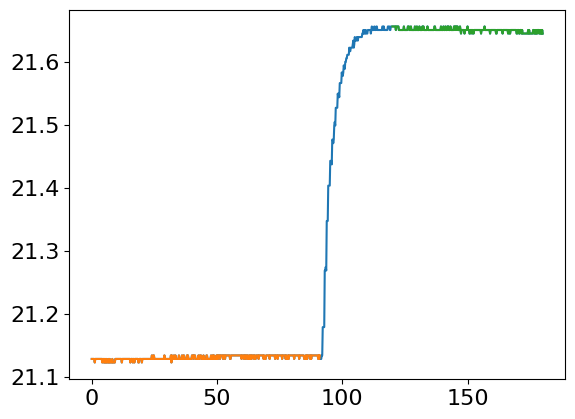

In [ ]:
# Put your code here to determine the bounds for pre- and post-reaction lines
# Create a plot and change the bounds to determine linearity
x1=91
x3=120

plt.plot(trial1.index,trial1['Temperature'],'C0')
plt.plot(trial1.loc[:x1].index,trial1['Temperature'].loc[:x1],'C1')
plt.plot(trial1.loc[x3:].index,trial1['Temperature'].loc[x3:],'C2')
plt.show()

In [ ]:
# Calculate the linear lines before and after
xdata=trial1.index
ydata=trial1['Temperature']

# Define the best fit lines using scipy.stats.linregress
Ti1=scipy.stats.linregress(trial1.loc[:x1].index,ydata.loc[:x1])
Tf1=scipy.stats.linregress(trial1.loc[x3:].index,ydata.loc[x3:])

# You can use LMFIT as well to do the linear regression and get the same results
lmodel1= Model(line)
lmodel2= Model(line)
Ti2 = lmodel1.fit(ydata.loc[:x1], x=trial1.loc[:x1].index, m=0.05,b=21)
Tf2 = lmodel2.fit(ydata.loc[x3:], x=trial1.loc[x3:].index, m=0.05,b=21)

# Verifies that both methods do indeed yield the same best fit parameters
print(Ti2.fit_report())
print(Ti1.slope,Ti1.stderr,Ti1.intercept,Ti1.intercept_stderr,Ti1.rvalue**2)
print(Tf2.fit_report())
print(Tf1.slope,Tf1.stderr,Tf1.intercept,Tf1.intercept_stderr,Tf1.rvalue**2)

[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 456
    # variables        = 2
    chi-square         = 0.00269544
    reduced chi-square = 5.9371e-06
    Akaike info crit   = -5485.64096
    Bayesian info crit = -5477.39598
    R-squared          = 0.46402956
[[Variables]]
    m:  8.5927e-05 +/- 4.3341e-06 (5.04%) (init = 0.05)
    b:  21.1264657 +/- 2.2784e-04 (0.00%) (init = 21)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, b) = -0.8655
8.592740899544699e-05 4.334124510450843e-06 21.1264657414872 0.00022783510474987505 0.46402956223133784
[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 301
    # variables        = 2
    chi-square         = 0.00181718
    reduced chi-square = 6.0775e-06
    Akaike info crit   = -3613.29183
    Bayesian info crit = -3605.87761
    R-squared          = 0.33189064
[[Variabl

In [ ]:
# Calculate the analytical logistic function with best fit parameters
# Prints out the statistics of the fit, including uncertainties

xdata=trial1.index
ydata=trial1['Temperature']

# Fit the data with initial conditions using LMFIT Model
gmodel1 = Model(logistic)

# Pick initial conditions for ydata, xdata, and fitting parameters
# x0 and B should be changed based on your information
# x0 is the time you hit the plunger
# B is the temperature
result1 = gmodel1.fit(ydata, x=xdata, L=0.6, x0=95, k=0.6, B=21.1)

# Return the best fit parameters
L=result1.params['L'].value
x0=result1.params['x0'].value
k=result1.params['k'].value
B=result1.params['B'].value

# Print the standard statistics of the fitting
print(result1.fit_report())

# Print the confidence interval values for each parameter
print(result1.ci_report())

[[Model]]
    Model(logistic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 41
    # data points      = 901
    # variables        = 4
    chi-square         = 0.10179930
    reduced chi-square = 1.1349e-04
    Akaike info crit   = -8180.51981
    Bayesian info crit = -8161.30579
    R-squared          = 0.99824584
[[Variables]]
    L:   0.51878883 +/- 7.4505e-04 (0.14%) (init = 0.6)
    x0:  95.2457012 +/- 0.03157252 (0.03%) (init = 95)
    k:   0.54102952 +/- 0.00808667 (1.49%) (init = 0.6)
    B:   21.1290037 +/- 5.0627e-04 (0.00%) (init = 21.1)
[[Correlations]] (unreported correlations are < 0.100)
    C(L, B)  = -0.6902
    C(L, k)  = -0.2235
    C(x0, B) = +0.1687
    C(k, B)  = +0.1543
       99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 L :  -0.00225  -0.00150  -0.00075   0.51879  +0.00075  +0.00150  +0.00225
 x0:  -0.09774  -0.06522  -0.03254  95.24570  +0.03264  +0.06559  +0.09863
 k :  -0.02482  -0.01672  -0.00845   0.5410

In [ ]:
# Calculate the analytical arctangent function with best fit parameters
# Prints out the statistics of the fit, including uncertainties

xdata=trial1.index
ydata=trial1['Temperature']

# Fit the data with initial conditions
gmodel2 = Model(ARCTAN)

# Pick initial conditions for ydata, xdata, and fitting parameters
result2 = gmodel2.fit(ydata, x=xdata, a=1, b=1, c=1, d=22 )

# Return the best fit parameters
aa=result2.params['a'].value
bb=result2.params['b'].value
cc=result2.params['c'].value
dd=result2.params['d'].value

# Print the standard statistics of the fitting
print(result2.fit_report())

# Print the confidence interval values for each parameter
print(result2.ci_report())

[[Model]]
    Model(ARCTAN)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7494
    # data points      = 901
    # variables        = 4
    chi-square         = 0.13236687
    reduced chi-square = 1.4757e-04
    Akaike info crit   = -7943.94049
    Bayesian info crit = -7924.72647
    R-squared          = 0.99771912
[[Variables]]
    a:  0.17023775 +/- 3.2215e-04 (0.19%) (init = 1)
    b:  0.62423257 +/- 0.01505674 (2.41%) (init = 1)
    c: -59.3215386 +/- 1.43086641 (2.41%) (init = 1)
    d:  21.3880587 +/- 4.1712e-04 (0.00%) (init = 22)
[[Correlations]] (unreported correlations are < 0.100)
    C(b, c) = -0.9999
    C(a, b) = -0.5368
    C(a, c) = +0.5366
      99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 a:  -0.00095  -0.00063  -0.00032   0.17024  +0.00032  +0.00064  +0.00096
 b:  -0.04072  -0.02756  -0.01403   0.62423  +0.01436  +0.02929  +0.04480
 c:  -4.24062  -2.77329  -1.35927 -59.32154  +1.32805  +2.60979  +3.85527
 d:  -0.0

In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

    <p><strong>What about using multiple functions?</strong></p>

 <p> After lab (or whenever you finish this notebook), build the following composite models to
  see if any of these can improve the \(r^2\) value:
  <ul>
    <li> <b> logistic + arctan </b> -- a combination of two functions that fits all parameters</li>
    <li> <b> c1*logistic + c2*arctan</b> -- fit c1 and c2 based off of the logistic and arctan curves that you already fit</li>
    <li> <b> line (pre-reaction) + exponential </b> -- using Ti1 for the pre-reaction line and fitting an exponential to all data after the reaction starts</li>
    <ul>
      <li> This version would require combining Ti1 with an exponential for everything else. See the figure below. </li>
      <center> <img width="500"
  src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Figures/fitted_data_line+exp.png?raw=True"> </center>
    </ul>
  </ul>
<p>
For a deeper explanation of LMFIT and the code for composite models, follow this link to read about
<a href="https://lmfit.github.io/lmfit-py/model.html" target="_blank">LMFIT Models</a>.
</p>

</div>

<font color=red> **Note to instructors:** Students would most likely not choose to explore the option of composite models as using a singular logistic function will yield a good correlation ($r^2 \approx$ 0.998) to the experimental thermograms. This is there in case students want to explore using composite models in future fittings and to see the documentation for LMFIT.  Below is an example of using line + exponential with an $r^2$ of 0.9996. </font>

<font color=red> The line + exponential model would benefit from using Simpson's method with a finite number of rectangles (50000 would be good enough for this purpose -- see sample code below) due to underestimation of error in the quadrature methods.</font>

<font color=red>  With an analytical formula provided for the fit, students can also manually compute the analytical solution to the integral and then apply that formula to calculate the definite integral. For example, the fitted region for the exponential function post-reaction takes place is $$ Ae^{-k(x-91)}+C$$ where $A$, $k$, and $C$ are the fitted parameters. The resulting analytical integral is
$$\int_{t_1}^{t_{mix}}Ae^{-k(x-91)}+C dx = \dfrac{-A}{k(x-91)}e^{-k(x-91)}+Cx\bigg|_{t_1}^{t_{mix}} = -A\bigg(\dfrac{e^{-k(t_{mix}-91)}}{k(t_{mix}-91)} - \dfrac{e^{-k(t_1-91)}}{k(t_1-91)}\bigg)+C(t_{mix}-t_1)$$ </font>

<font color=red>  With an analytical antiderivative expression, another Python function can be created to compute the area under the curves with pre-defined bounds.</font>

Combined r²: 0.999613
tmix T63R: 96.07372
tmix area: 96.15260
ΔT for T63R: 0.52069
ΔT for equivalent areas: 0.52067


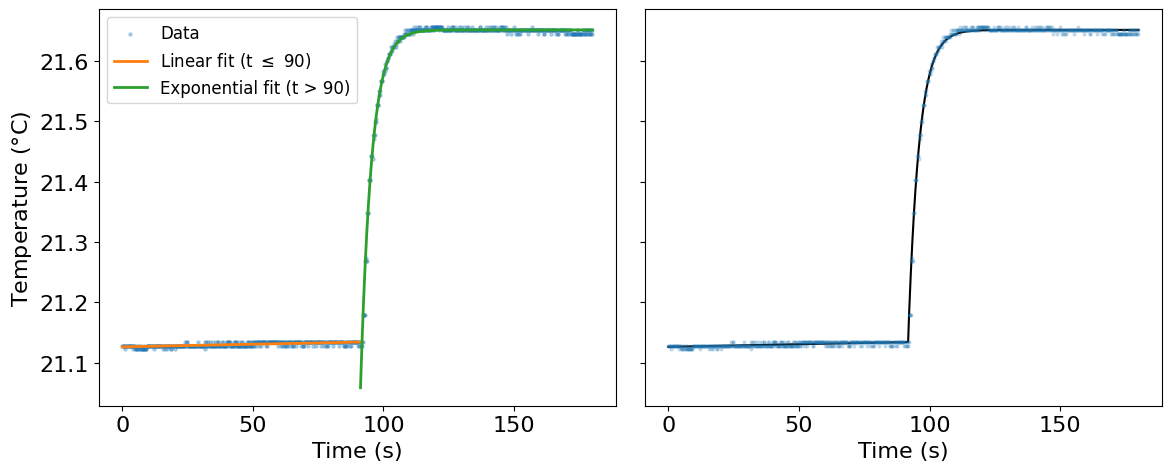

In [ ]:
# @title #### Sample Code for line+exponential fit
# @markdown The code here runs through the exponential fit with a function that manually computes the $r^2$ value.
# @markdown * Once the line+exponential model is fit, the methods used below to calculate $\Delta T$ are used. They are renamed so they do not overlap with existing functions.
# @markdown * Simpson's rule was used to integrate the thermogram due to repeated underestimation of error using the quadrature method.

def r_squared(ydata,ycombined):
  ''' Compute r^2 of fitted data'''
  # Residual sum of squares
  ss_res = np.sum((ydata - y_combined) ** 2)

  # Total sum of squares
  ss_tot = np.sum((ydata - np.mean(ydata)) ** 2)

  # R-squared
  r_squared_combined = 1 - (ss_res / ss_tot)

  print(f"Combined r²: {r_squared_combined:.6f}")

time = xdata  # your time data
temp = ydata  # your temperature data

x1=91
x3=120

# Step 1: linear fit to time <= 90
mask_linear = time <= x1
time_linear = time[mask_linear]
temp_linear = temp[mask_linear]

linear_model = Model(line)
linear_result = linear_model.fit(temp_linear, x=time_linear, m=0.1, b=20)

# Step 2: exponential fit to time > x1
mask_exp = time > x1
time_exp = time[mask_exp]
temp_exp = temp[mask_exp]

def exponential(x, A, k, C):
    return A * np.exp(-k*(x - 91)) + C

exp_model = Model(exponential)
exp_result = exp_model.fit(temp_exp, x=time_exp, A=1.0, k=0.1, C=20)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5),sharey=True)

# Plotting both fits
ax1.scatter(time, temp, s=5, alpha=0.3, label='Data')

# Plot linear fit
ax1.plot(time_linear, linear_result.best_fit, 'C1', lw=2, label=r'Linear fit (t $\leq$ 90)')

# Plot exponential fit
ax1.plot(time_exp, exp_result.best_fit, 'C2', lw=2, label=r'Exponential fit (t > 90)')

ax1.set_xlabel(r'Time (s)')
ax1.set_ylabel(r'Temperature ($\degree$C)')
ax1.legend(fontsize=12)

# Optional: print fit reports
#print("Linear Fit Report:\n", linear_result.fit_report())
#print("\nExponential Fit Report:\n", exp_result.fit_report())

def Y_combined(x2,xdata,linear_result,exp_result):
  # Split xdata based on condition
  x_linear = xdata[xdata < x2]
  x_exp = xdata[xdata >= x2]

  # Calculate predicted y values from each segment
  y_linear_fit = line(x_linear, linear_result.params['m'].value,linear_result.params['b'].value)
  y_exp_fit = exponential(x_exp, exp_result.params['A'].value,exp_result.params['k'].value,exp_result.params['C'].value)

  # Combine into one full predicted y array (same length and order as xdata)
  y_combined = np.empty_like(xdata)

  # Fill values accordingly
  y_combined[xdata < x2] = y_linear_fit
  y_combined[xdata >= x2] = y_exp_fit

  return y_combined

y_combined = Y_combined(92,xdata,linear_result,exp_result)

ax2.plot(xdata,y_combined,'k-')
ax2.set_xlabel('Time (s)')
ax2.plot(xdata,ydata,'C0o',markersize=2,alpha=0.2)
plt.tight_layout()

r_squared(ydata,y_combined)
ex = interp(xdata,y_combined)

# T63 method
def diff_T63_exp(x2):

  # Define the points along the best fit lines and the thermogram
  # Use the line functions for yi and yf
  yi=line(x2,Ti1.slope,Ti1.intercept)
  yf=line(x2,Tf1.slope,Tf1.intercept)

  # Define which best fit function you are using for y
  y=ex(x2)

  # Calculate the ratio between the y values of the best fit lines
  # and the analytical function for the thermogram (You will code this)
  dy=(y-yi)/(yf-yi)

  # Return the absolute value of the difference between dy and 0.632 (63.2%)
  return np.abs(dy-0.632)


# Run the minimize scalar optimization procedure
g2=scipy.optimize.minimize_scalar(diff_T63_exp,bounds=(x1,x3))
print("tmix T63R:",'%0.5f'%g2.x)

# The best fit parameters you defined earlier will carry over into these lines
def diff_EqualAreas_exp(x2, x1, x3):
  '''
  x1 is lower intergration limit
  x2 is middle integration limit and will be tmix
  x3 is upper integration limit
  '''

  # Choose the number of rectangles used for Simpson's rule


  # Generate x values for Simpson's rule
  num_rectangles=10000
  x_lo = np.linspace(x1, x2, num_rectangles).flatten()
  x_hi = np.linspace(x2, x3, num_rectangles).flatten()
  y_lo = ex(x_lo)
  y_hi = ex(x_hi)

  # Calculate area B (Thermogram Best Fit Curve - Temp Init Line)
  Thermo_init=scipy.integrate.simpson(y_lo, x_lo)
  Line_init=scipy.integrate.quad(line, x1, x2, args=(Ti1.slope, Ti1.intercept))[0]
  # Calculate area A (Temp final line - Thermogram Best Fit Curve)
  Thermo_final=scipy.integrate.simpson(y_hi, x_hi)
  Line_final=scipy.integrate.quad(line, x2, x3, args=(Tf1.slope, Tf1.intercept))[0]

  # Calculate the areas (You will code this)
  area_A= Line_final - Thermo_final
  area_B= Thermo_init - Line_init

  # Once you calculate area_A and area_B, then calculate the absolute value of
  # the difference between areas (You will code this)
  area_diff = np.abs(area_A-area_B)

  # Return the absolute value of the difference between areas (You will code this)
  return area_diff # Convert to scalar

h2 = scipy.optimize.minimize(diff_EqualAreas_exp, x0=x1+0.1,args=(x1, x3), bounds=[(x1, x3)])

# Print the output x value for t_mix.
# h2.x is an array when using minimize, so h.x[0] calls the value we need
print('tmix area:','%0.5f'%h2.x[0])

# Calculate Delta T with each method
deltaT_T63_exp=line(g2.x,Tf1.slope,Tf1.intercept)-line(g2.x,Ti1.slope,Ti1.intercept)
deltaT_EQA_exp=line(h2.x[0],Tf1.slope,Tf1.intercept)-line(h2.x[0],Ti1.slope,Ti1.intercept)
print('ΔT for T63R:','%0.5f'%deltaT_T63_exp)
print('ΔT for equivalent areas:','%0.5f'%deltaT_EQA_exp)

In [ ]:
# @title Exercise: Creating Representative Figures
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
Create a representative figure of this method that displays the following:
<ul>
  <li> the thermogram </li>
  <li> the best fit lines </li>
  <li> the sigmoid fitting function </li>
  <li> the \(T_{63R}\) line </li>
  <li> Include axes labels and units but no plot title</li>
</ul>
This figure will be the base of what goes in the lab report to model the various components of this analysis.
</div>

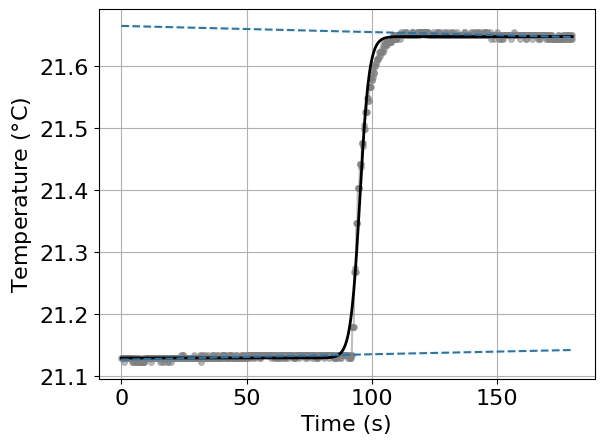

In [ ]:
# You can use the code from the pre-lab assignment to plot the best fit model

plt.plot(xdata,ydata,'o-',color='grey',alpha=0.5,markersize=4)
plt.plot(xdata, result1.best_fit, '-', label='Best Fit',color='k',lw=2)
#plt.plot(xdata, result1.best_fit, '-', label='logistic',color='k',lw=2)
plt.plot(xdata,line(xdata,Ti1.slope, Ti1.intercept),'C0--')
plt.plot(xdata,line(xdata,Tf1.slope, Tf1.intercept),'C0--')

plt.xlabel(r'Time (s)')
plt.ylabel(r'Temperature ($\degree$C)')
plt.grid(True)
plt.show()

## 1.4 T$_{.63R}$


In [ ]:
# @title Exercise: Interpret the $T_{.63R}$ method
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
\(T_{.63R}\) is the temperature that is 63.2% of \(\Delta T\) above \(T_i\).

$$
	T_{.63R}=T_i + (\Delta T \times 0.632)
$$

<p>\(\Delta T\) is the difference between the extrapolated pre-reaction trend and the extrapolated post-reaction trend on a
vertical line at the equivalent instantaneous mixing time (\(t_\text{mix}\)), which intersects the thermogram at \(T_{.63R}\).
This analysis should be done numerically, fitting both the pre-reaction and post reaction data to a straight line.</p>

By minimizing the difference between the intersection between the \(T_{.63R}\) line
(the line that sits at 63.2% between \(T_i\) and \(T_f\)) and the thermogram, \(t_\text{mix}\),
which intersects the thermogram at \(T_{.63R}\), can be found and can then be extrapolated to solve for \(\Delta T\).

<p> <b>Interpret the Python function called diff_T63. What does it do? Fill in the blanks in the function to make it run correctly.</b></p>
<p> Then, in the two cells below, create new versions of diff_T63 that will run the regression on other functions (arctangent, logistic, interpolation). </p>
</div>

In [ ]:
def diff_T63(x2):

  # Define the points along the best fit lines and the thermogram
  # Use the line functions for yi and yf
  yi=line(x2,Ti1.slope,Ti1.intercept)
  yf=line(x2,Tf1.slope,Tf1.intercept)

  # Define which best fit function you are using for y
  y=logistic(x2,L,x0,k,B)

  # Calculate the ratio between the y values of the best fit lines
  # and the analytical function for the thermogram (You will code this)
  dy=(y-yi)/(yf-yi)

  # Store the iteration into a global list
  diff1_data.append((x2, y))

  # Return the absolute value of the difference between dy and 0.632 (63.2%)
  return np.abs(dy-0.632)

In [ ]:
# Practice cell to test different parts of the calculation before putting it in the function





In [ ]:
# Try running different values of diff_T63 to see how it works






In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <strong> Note: </strong> </p>

<code>scipy.optimize.minimize_scalar</code> is a <b>Python function used to find the minimum value of a single-variable function</b>
— that is, it tries to solve:

$$
\min_x f(x)
$$

Where \(f(x)\) is a function that returns a number (a scalar), and you want to find the value of \(x\) that makes \(f(x)\) as small as possible.

Use <code>minimize_scalar</code> when:
<ul>
<li> You have a <b>function of one variable</b> (like a cost, energy, error, etc.).</li>
<li> You want to <b>find the input \(x\) that gives the smallest output</b>.</li>
<li> You don’t need to compute gradients or use multi-variable optimization.</li>
</ul>
</div>

<style>

In [ ]:
# Find where T63R intersects the thermogram through an optimization procedure.

# Set the bounds to those of the curve of the thermogram (x1 and x3).
x1=90
x3=120

# Define the global list diff1_data to store the iterations
diff1_data=[]

# Run the minimize scalar optimization procedure
g=scipy.optimize.minimize_scalar(diff_T63,bounds=(x1,x3))
print("tmix T63R:",g.x)

tmix T63R: 96.35193685222961


In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <strong> Note: </strong> </p>
<p> The animation below uses <code>result1.best_fit</code> to represent the thermogram.
  Make sure whichever fitting function you are using from LMFIT is labeled as <code>result1</code>.</p>
 The thermogram data is labeled as <code>xdata</code> and <code>ydata</code>.</p>
</div>

<style>

### Visualize the optimization process

The below cell will play an animation of the optimization process. Press the play button to run the animation.

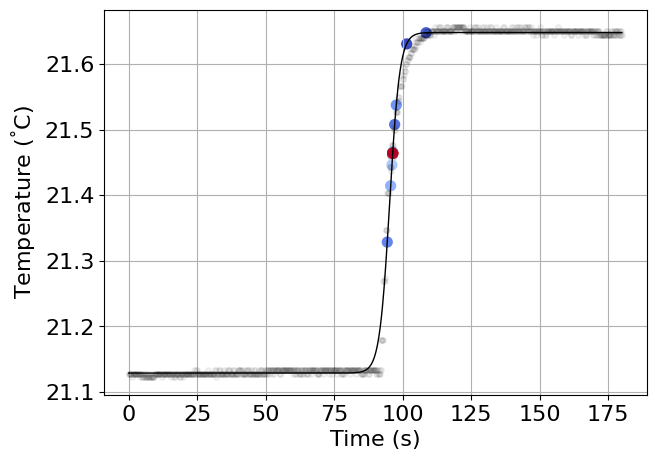

In [ ]:
# @title Hit the play button

from IPython.display import display, clear_output
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Extract x and function values from the stored data
iterations = [data[0] for data in diff1_data]
function_values = [data[1] for data in diff1_data]

# Create a figure and axes
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the thermogram and the best fit logistic curve
ax.plot(xdata, ydata, 'ko', alpha=0.05, markersize=4)
ax.plot(xdata, result1.best_fit, '-', label='Best Fit', color='k', lw=1)

# Set axes labels and title
ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'Temperature ($^\degree$C)')
ax.grid(True)

# Create a scatter plot object for the iterations
# Initialize with empty data but set up the colormap
scatter = ax.scatter([], [], c=[], s=50, cmap='coolwarm', vmin=0, vmax=len(iterations)-1)

# Display the initial plot
display(fig)

# Iterate through the stored data and update the scatter plot
for i in range(len(iterations)):
    # Update the scatter plot data
    scatter.set_offsets(np.c_[iterations[:i+1], function_values[:i+1]])
    # Assign colors based on the iteration number
    # Use a range from 0 to the current iteration index to map to the colormap
    scatter.set_array(np.arange(i + 1))

    # Clear the previous output and display the updated figure
    clear_output(wait=True)
    display(fig)
    time.sleep(0.25)  # Small delay to visualize the update

# Close the figure after the loop finishes
plt.close(fig)

In [ ]:
# @title **Question 3**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">

    <p>Put your observations about the animation and the T63R method below.</p>
  <p>
</div>

---


**Answer goes here**

---

## 1.5 Equivalent Areas

Define the integrals and then calculate the difference between the two areas A and B.

<div>
  <center> <img height="400" src="https://github.com/pmpatel-udallas/CHE-3131/blob/main/Rotation-2-Calorimetry/Figures/Thermogram_VariableDiagram.png?raw=True"> </center>
</div>

In [ ]:
# @title Exercise: Interpret the Equivalent Areas method
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>

<p>
In calorimetry experiments, the heat released or absorbed would ideally cause an immediate jump in temperature,
but in real systems, the temperature changes gradually due to mixing and thermal lag.
</p>

<p>
To accurately measure the total heat change, we use the <strong>equivalent areas method</strong>.
This method accounts for the delayed temperature response by comparing the experimental temperature data
to what the temperature would have been without the reaction.
</p>


<p>
The area between the experimental curve and the baselines represents the total temperature change caused by the reaction,
spread out over time. We treat this area as if it came from an <em>instantaneous</em> temperature change (\(t_2\)):
</p>

$$ \int_{t_1}^{t_2} \left[ T_{\text{exp}}(t) - T_i(t) \right] dt
  =
  \int_{t_2}^{t_3} \left[ T_f(t) - T_{\text{exp}}(t) \right] dt
$$

<p>
This gives an <strong>equivalent temperature change</strong> \( \Delta T_{\text{eq}} \),
which can then be used in the usual calorimetry formula:
</p>

<p style="text-align: center;">
  \( q = C_{cal} \cdot \Delta T_{\text{eq}} \)
</p>

<p>
This method works even if the temperature curve is not smooth or has some delay
because it focuses on the <em>total thermal effect</em> and not just the peak temperature.
</p>

<p> <strong> Questions: </strong></p>
<ul>
<li> What does this function do? What are the steps involved? </li>
<li> What are the roles of x1, x2, and x3 in this function?</li>
<li> You will calculate the areas under the respective curves using <code>scipy.integrate</code> functions,
  how will you calculate the area between two curves?</li>
</ul>

</div>

In [ ]:
# The best fit parameters you defined earlier will carry over into these lines
def diff_EqualAreas(x2, x1, x3):
  '''
  x1 is lower integration limit
  x2 is middle integration limit and will be tmix
  x3 is upper integration limit
  '''

  # Calculate area B (Thermogram Best Fit Curve - Temp Init Line)
  Thermo_init=scipy.integrate.quad(logistic, x1, x2, args=(L, x0, k, B))[0]
  Line_init=scipy.integrate.quad(line, x1, x2, args=(Ti1.slope, Ti1.intercept))[0]

  # Calculate area A (Temp final line - Thermogram Best Fit Curve)
  Thermo_final=scipy.integrate.quad(logistic, x2, x3, args=(L, x0, k, B))[0]
  Line_final=scipy.integrate.quad(line, x2, x3, args=(Tf1.slope, Tf1.intercept))[0]

  # Calculate the areas (You will code this)
  area_A= Line_final - Thermo_final
  area_B= Thermo_init - Line_init

  # Once you calculate area_A and area_B, then calculate the absolute value of
  # the difference between areas (You will code this)
  area_diff = np.abs(area_A-area_B)

  # Append the values to the global list
  diff2_data.append((x2, logistic(x2,L,x0,k,B)))

  # Return the absolute value of the difference between areas (You will code this)
  return area_diff

In [ ]:
# Practice cell to test different parts of the calculation before putting it in the function





In [ ]:
# Try running different values of diff_EqualAreas to see how it works




In [ ]:
# Create a global list to store the data
diff2_data = []

# Define the values for x1 and x3 (integration bounds)
x1 = 90
x3 = 120

# We will use minimize instead of minimize_scalar to handle multiple arguments (x1 and x3)
# We have to provide an initial guess x0 which is set to x1+0.5 so it can run the visualization code
h = scipy.optimize.minimize(diff_EqualAreas, x0=x1+0.5,args=(x1, x3), bounds=[(x1, x3)])

# Print the output x value for t_mix.
# h.x is an array when using minimize, so h.x[0] calls the value we need
print('tmix area:','%0.5f'%h.x[0])

tmix area: 95.71224


### Visualize the optimization process

The below cell will play an animation of the optimization process. Press the play button to run the animation.

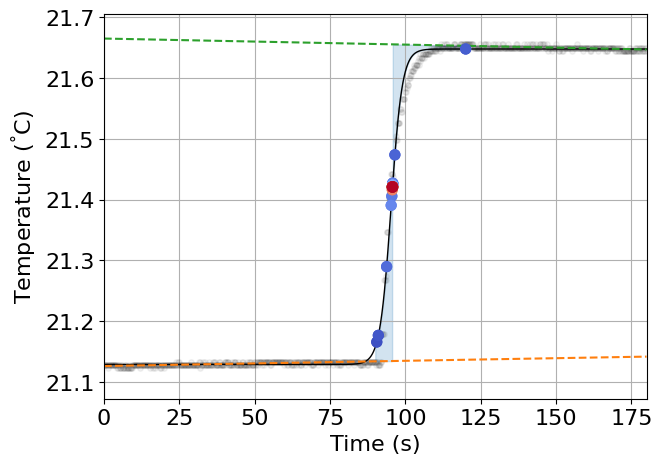

In [ ]:
# @title Hit the play button

from IPython.display import display, clear_output
import time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Extract x and function values from the stored data
# Ensure iterations and function_values are numpy arrays for easier slicing
iterations = np.array([data[0] for data in diff2_data]).flatten() # Flatten the arrays if they contain single-element arrays
function_values = np.array([data[1] for data in diff2_data])

# Create a figure and axes
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the thermogram and the best fit logistic curve once outside the loop
ax.plot(xdata, ydata, 'ko', alpha=0.05, markersize=4, label='Data')
ax.plot(xdata, result1.best_fit, '-', label='Best Fit (Logistic)', color='k', lw=1)


# Set axes labels and title
ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'Temperature ($^\degree$C)')
ax.grid(True)

# Create a scatter plot object for the iterations
# Initialize with empty data but set up the colormap
# Set zorder higher to ensure points are on top
scatter = ax.scatter([], [], c=[], s=50, cmap='coolwarm', vmin=0, vmax=len(iterations)-1, zorder=10) # Increased zorder


# Initialize lists to store lines and collections to be removed
lines_to_remove = []
collections_to_remove = []

# Iterate through the stored data and update the scatter plot
for i in range(len(iterations)):
    # Remove lines and collections from the previous iteration
    for line_obj in lines_to_remove:
        line_obj.remove()
    for collection_obj in collections_to_remove:
        collection_obj.remove()

    # Clear the lists for the current iteration
    lines_to_remove = []
    collections_to_remove = []

    # Update the scatter plot data with cumulative points up to the current iteration
    scatter.set_offsets(np.c_[iterations[:i+1], function_values[:i+1]])
    # Assign colors based on the iteration number
    scatter.set_array(np.arange(i + 1))

    x2_tmp = iterations[i]

    # Define integration bounds based on the current x2_tmp
    xlo2_mask = (xdata >= x1) & (xdata <= x2_tmp)
    xlo2 = xdata[xlo2_mask]

    xhi2_mask = (xdata >= x2_tmp) & (xdata <= x3)
    xhi2 = xdata[xhi2_mask]

    # Plot the best fit lines (assuming Ti1 and Tf1 are defined) in each iteration
    line1, = ax.plot(xdata, line(xdata, Ti1.slope, Ti1.intercept), 'C1--', label='pre-reaction line')
    line2, = ax.plot(xdata, line(xdata, Tf1.slope, Tf1.intercept), 'C2--', label='post-reaction line')
    # Add lines to the remove list
    lines_to_remove.extend([line1, line2])

    # Plot the filled areas in each iteration
    fill1 = ax.fill_between(xlo2, line(xlo2, Ti1.slope, Ti1.intercept),
                     logistic(xlo2, L, x0, k, B), color='C0', alpha=0.2)
    fill2 = ax.fill_between(xhi2, line(xhi2, Tf1.slope, Tf1.intercept),
                     logistic(xhi2, L, x0, k, B), color='C0', alpha=0.2)

    # Add collections to the remove list
    collections_to_remove.extend([fill1, fill2])


    # Ensure the limits are consistent if needed
    ax.set_xlim(xdata.min(), xdata.max())
    ax.set_ylim(ydata.min() - 0.05, ydata.max() + 0.05)

    # Update the legend to include the dynamically added lines/fills if needed (optional)
    # ax.legend()


    # Clear the previous output and display the updated figure
    clear_output(wait=True)
    display(fig)
    time.sleep(0.25)  # Small delay to visualize the update

# Close the figure after the loop finishes
plt.close(fig)

In [ ]:
# @title **Question 4**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
    <p>Put your observations about the animation and the equivalent areas method below.</p>
</div>

---


**Answer goes here**

---

## 1.6 Calculate $\Delta T$ from both methods

In [ ]:
# Calculate Delta T with each method
deltaT_T63=line(g.x,Tf1.slope,Tf1.intercept)-line(g.x,Ti1.slope,Ti1.intercept)
deltaT_EQA=line(h.x[0],Tf1.slope,Tf1.intercept)-line(h.x[0],Ti1.slope,Ti1.intercept)

print('ΔT for T63R:','%0.5f'%deltaT_T63)
print('ΔT for equivalent areas:','%0.5f'%deltaT_EQA)

ΔT for T63R: 0.52063
ΔT for equivalent areas: 0.52075


In [ ]:
# @title **Question 5**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
    <p>What are your initial thoughts on the calculated \( \Delta T\) between the two methods?
      Make a note in your physical lab notebook or here in the digital notebook.</p>
</div>

---


**Answer goes here**

---

# Part 2. Calculate $\Delta H$


In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <strong> Note: </strong> </p>

<p> Use a numpy array to calculate the values using the computed \( \Delta T\) from both methods at the same time.

<style>

In [ ]:
mass_total=120.065000
moles_NaOH=0.005209
C_cal=89.44+4.184*mass_total
q_sys=C_cal*np.array([deltaT_T63,deltaT_EQA])
deltaH=-q_sys/(1000*moles_NaOH)

print('ΔH',deltaH)

ΔH [-59.14893924 -59.16242625]


## 2.1 Repeat this analysis for every trial

In [ ]:
# @title Exercise: Repeating a procedure
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
<p> Now that you have the results for \( \Delta H \) for one trial, do the same analysis for the other trials.<p>
<p> Think about how you can combine the code blocks you did above into a new block below to calculate \( \Delta H \) for  <b> each </b> trial.</p>
<p> This may take on the form of copy+paste the relevant cells from above here and change the values based on each trial
  ...or perhaps one function that combines it all? </p>
</div>

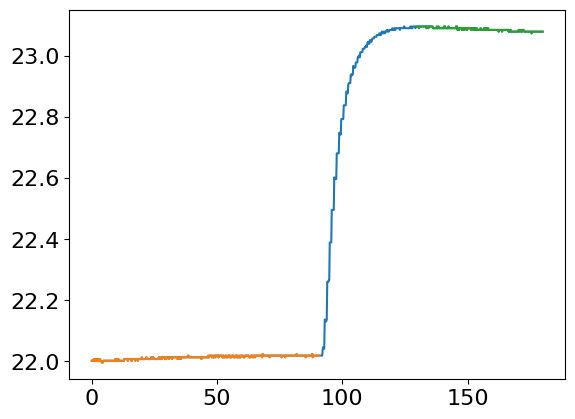

In [ ]:
# Identify the bounds for the linear lines pre- and post-reaction
# Plot the values as we did for the first trial to see which values
x1=91
x3=130

plt.plot(trial2.index,trial2['Temperature'],'C0')
plt.plot(trial2.loc[:x1].index,trial2['Temperature'].loc[:x1],'C1')
plt.plot(trial2.loc[x3:].index,trial2['Temperature'].loc[x3:],'C2')
plt.show()

In [ ]:
# The copy-paste method and change the trial numbers

x1=91
x3=130

# Calculate the linear lines before and after
xdata=trial2.index
ydata=trial2['Temperature']

# Define the best fit lines using scipy.stats.linregress
Ti1=scipy.stats.linregress(trial2.loc[:x1].index,ydata.loc[:x1])
Tf1=scipy.stats.linregress(trial2.loc[x3:].index,ydata.loc[x3:])

print(Ti1.slope,Ti1.stderr,Ti1.intercept,Ti1.intercept_stderr,Ti1.rvalue**2)
print(Tf1.slope,Tf1.stderr,Tf1.intercept,Tf1.intercept_stderr,Tf1.rvalue**2)

# Calculate the analytical logistic function with best fit parameters
# Prints out the statistics of the fit, including uncertainties

xdata=trial2.index
ydata=trial2['Temperature']

# Fit the data with initial conditions using LMFIT Model
gmodel1 = Model(logistic)

# Pick initial conditions for ydata, xdata, and fitting parameters
# x0 and B should be changed based on your information
# x0 is the time you hit the plunger
# B is the temperature you set the y axis to
result1 = gmodel1.fit(ydata, x=xdata, L=0.6, x0=95, k=0.6, B=21.1)

# Return the best fit parameters
L=result1.params['L'].value
x0=result1.params['x0'].value
k=result1.params['k'].value
B=result1.params['B'].value

# Print the standard statistics of the fitting
print(result1.fit_report())

# Print the confidence interval values for each parameter
print(result1.ci_report())

# Define the global list diff1_data to store the iterations
diff1_data=[]

# Run the minimize scalar optimization procedure
g=scipy.optimize.minimize_scalar(diff_T63,bounds=(x1,x3))
print("tmix T63R:",g.x)


# Create a global list to store the data
diff2_data = []

# Define the values for x1 and x3 (integration bounds)
x1 = 91
x3 = 130

# We will use minimize instead of minimize_scalar to handle multiple arguments (x1 and x3)
# We have to provide an initial guess x0 which is set to x1+0.5 so it can run the visualization code
h = scipy.optimize.minimize(diff_EqualAreas, x0=x1+0.5,args=(x1, x3), bounds=[(x1, x3)])

# Print the output x value for t_mix.
# h.x is an array when using minimize, so h.x[0] calls the value we need
print('tmix area:','%0.5f'%h.x[0])

# Calculate Delta T with each method
deltaT_T63=line(g.x,Tf1.slope,Tf1.intercept)-line(g.x,Ti1.slope,Ti1.intercept)
deltaT_EQA=line(h.x[0],Tf1.slope,Tf1.intercept)-line(h.x[0],Ti1.slope,Ti1.intercept)

print('ΔT for T63R:','%0.5f'%deltaT_T63)
print('ΔT for equivalent areas:','%0.5f'%deltaT_EQA)

mass_total=120.053
moles_NaOH=0.010341
C_cal=89.44+4.184*mass_total
q_sys=C_cal*np.array([deltaT_T63,deltaT_EQA])
deltaH=-q_sys/(1000*moles_NaOH)

print('ΔH',deltaH)


0.00020419675050278868 4.927091701467345e-06 22.003925495220546 0.00025900604636743153 0.7909353992020137
-0.0003587440713337301 1.007381277948555e-05 23.14289138683362 0.0015682503289995901 0.8358799815931547
[[Model]]
    Model(logistic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 51
    # data points      = 901
    # variables        = 4
    chi-square         = 0.42281290
    reduced chi-square = 4.7136e-04
    Akaike info crit   = -6897.56202
    Bayesian info crit = -6878.34800
    R-squared          = 0.99825409
[[Variables]]
    L:   1.07107020 +/- 0.00155288 (0.14%) (init = 0.6)
    x0:  97.3915379 +/- 0.03747892 (0.04%) (init = 95)
    k:   0.38457385 +/- 0.00483975 (1.26%) (init = 0.6)
    B:   22.0095647 +/- 0.00103546 (0.00%) (init = 21.1)
[[Correlations]] (unreported correlations are < 0.100)
    C(L, B)  = -0.6825
    C(L, k)  = -0.2679
    C(x0, B) = +0.1965
    C(k, B)  = +0.1829
       99.73%    95.45%    68.27%    _BEST_    68.27%    

In [ ]:
# The create a function method
# Change the variables to generalize the process
# Can use existing variables as a placeholder, which redefines it as a local variable within the function.
# Think about which variables need to be replaced in the manual version
# Then generalize that part of the function
def determine_deltaH(x1,x3,trial2,m_total,n_NaOH):
  '''
  x1=91 (time pre-reaction)
  x3=130 (time post-reaction)
  trial2 (trial number -- pandas DataFrame)
  m_total (calculated total mass of HCl + NaOH)
  n_NaOH (calculated moles of NaOH)
  '''

  # Calculate the linear lines before and after
  xdata=trial2.index
  ydata=trial2['Temperature']

  # Define the best fit lines using scipy.stats.linregress
  Ti1=scipy.stats.linregress(trial2.loc[:x1].index,ydata.loc[:x1])
  Tf1=scipy.stats.linregress(trial2.loc[x3:].index,ydata.loc[x3:])

  #print(Ti1.slope,Ti1.stderr,Ti1.intercept,Ti1.intercept_stderr,Ti1.rvalue**2)
  #print(Tf1.slope,Tf1.stderr,Tf1.intercept,Tf1.intercept_stderr,Tf1.rvalue**2)

  # Calculate the analytical logistic function with best fit parameters
  # Prints out the statistics of the fit, including uncertainties

  xdata=trial2.index
  ydata=trial2['Temperature']

  # Fit the data with initial conditions using LMFIT Model
  gmodel1 = Model(logistic)

  # Pick initial conditions for ydata, xdata, and fitting parameters
  # x0 and B should be changed based on your information
  # x0 is the time you hit the plunger
  # B is the temperature you set the y axis to
  result1 = gmodel1.fit(ydata, x=xdata, L=0.6, x0=95, k=0.6, B=21.1)

  # Return the best fit parameters
  L=result1.params['L'].value
  x0=result1.params['x0'].value
  k=result1.params['k'].value
  B=result1.params['B'].value

  # Print the standard statistics of the fitting
  #print(result1.fit_report())

  # Print the confidence interval values for each parameter
  #print(result1.ci_report())

  # Define the global list diff1_data to store the iterations
  diff1_data=[]

  # Run the minimize scalar optimization procedure
  g=scipy.optimize.minimize_scalar(diff_T63,bounds=(x1,x3))
  #print("tmix T63R:",g.x)


  # Create a global list to store the data
  diff2_data = []

  # We will use minimize instead of minimize_scalar to handle multiple arguments (x1 and x3)
  # We have to provide an initial guess x0 which is set to x1+0.5 so it can run the visualization code
  h = scipy.optimize.minimize(diff_EqualAreas, x0=x1+0.5,args=(x1, x3), bounds=[(x1, x3)])

  # Print the output x value for t_mix.
  # h.x is an array when using minimize, so h.x[0] calls the value we need
  #print('tmix area:','%0.5f'%h.x[0])

  # Calculate Delta T with each method
  deltaT_T63=line(g.x,Tf1.slope,Tf1.intercept)-line(g.x,Ti1.slope,Ti1.intercept)
  deltaT_EQA=line(h.x[0],Tf1.slope,Tf1.intercept)-line(h.x[0],Ti1.slope,Ti1.intercept)

  print('ΔT for T63R:','%0.5f'%deltaT_T63)
  print('ΔT for equivalent areas:','%0.5f'%deltaT_EQA)

  mass_total=m_total
  moles_NaOH=n_NaOH
  C_cal=89.44+4.184*mass_total
  q_sys=C_cal*np.array([deltaT_T63,deltaT_EQA])
  deltaH=-q_sys/(1000*moles_NaOH)

  print('ΔH',deltaH)

In [ ]:
determine_deltaH(91,130,trial2,120.053,0.010341)

ΔT for T63R: 1.08322
ΔT for equivalent areas: 1.08361
ΔH [-61.98474147 -62.00743328]


### Sample Calculations

In [ ]:
measurements=pd.read_excel('Calorimetry_SampleData.xlsx',sheet_name='Measurements',index_col=0)
results=pd.read_excel('Calorimetry_SampleData.xlsx',sheet_name='Results',index_col=0)

In [ ]:
measurements

,Trial1,Trial2,Trial3
Mass HCl (g),114.978000,109.955000,105.098000
Mass NaOH (g),5.087000,10.098000,14.459000
Total Mass (g),120.065000,120.053000,119.557000
[NaOH] (M),1.065000,1.065000,1.065000
Moles NaOH (mol),0.005209,0.010341,0.014807


In [ ]:
determine_deltaH(91,120,trial1,120.065000,0.005209)

ΔT for T63R: 0.52014
ΔT for equivalent areas: 0.52030
ΔH [-59.09241135 -59.11065998]


In [ ]:
determine_deltaH(90,120,trial2,120.053000,0.010341)

ΔT for T63R: 1.07718
ΔT for equivalent areas: 1.07762
ΔH [-61.63954137 -61.66433451]


In [ ]:
determine_deltaH(92,140,trial3,119.557000,0.014807)

ΔT for T63R: 1.60498
ΔT for equivalent areas: 1.60514
ΔH [-63.91576765 -63.92224623]


In [ ]:
# Don't forget about error propagation

# Calculate the base values
mass_HCl=105.098000
mass_NaOH=14.459000
mass_total=mass_HCl+mass_NaOH
moles_NaOH = mass_NaOH/1.04*1.065/1000
C_cal=89.44+4.184*mass_total
q_sys=C_cal*deltaT_EQA
Delta_H = -q_sys/(1000*moles_NaOH)

# Propagate the errors
e_mass_HCl = 0.005
e_mass_NaOH = 0.005
e_mass_total = 0.01
e_conc_NaOH = 0.065 # 95% CI of standardized NaOH solution used for data
e_mols_NaOH = moles_NaOH*e_mass_NaOH/mass_NaOH
e_C_cal = C_cal*e_mass_total/mass_total
e_DeltaT = 0.006
e_q_sys = q_sys*np.sqrt((e_DeltaT/deltaT_EQA)**2+(e_C_cal/C_cal)**2)
e_DeltaH = -1 * Delta_H * np.sqrt((e_q_sys/q_sys)**2+(e_mols_NaOH/moles_NaOH)**2)

print(f'mol_NaOH (1σ): {e_mols_NaOH:.0e}')
print(f'C_cal (1σ): {e_C_cal:0.2f}')
print(f'q_sys (1σ): {e_q_sys:0.0f}')
print(f'ΔH (1σ): {e_DeltaH:0.1f}')

mol_NaOH (1σ): 5e-06
C_cal (1σ): 0.05
q_sys (1σ): 4
ΔH (1σ): 0.2


In [ ]:
results

,Trial1,Trial2,Trial3
Mass HCl (g),114.978000,109.955000,105.098000
Mass NaOH (g),5.087000,10.098000,14.459000
Total Mass (g),120.065000,120.053000,119.557000
[NaOH] (M),1.065000,1.065000,1.065000
Moles NaOH (mol),0.005209,0.010341,0.014807
C_calorimeter (J/°C),591.791960,591.741752,589.666488
ΔT (°C),0.520180,1.083470,1.605140
q_sys (J),307.838342,641.134436,946.497267
ΔH (kJ/mol),-59.094179,-62.000825,-63.924132


In [ ]:
# Use arithmetic here to calculate Delta H for your trials
# This will be used to calculate the heat of reaction

# This loop is for the sample data
for i in ['Trial1','Trial2','Trial3']:
  mass_HCl=measurements.loc['Mass HCl (g)',i]
  mass_NaOH=measurements.loc['Mass NaOH (g)',i]
  mass_total=measurements.loc['Total Mass (g)',i]
  conc_NaOH=measurements.loc['[NaOH] (M)',i]
  moles_NaOH=mass_NaOH/1.040*conc_NaOH/1000

  C_cal=89.44+4.184*mass_total
  delta_T=(Tf1.slope*h.x+Tf1.intercept)-(Ti1.slope*h.x+Ti1.intercept) # What the students will calculate
  delta_T=results.loc['ΔT (°C)',i] # Using sample data
  q_sys=C_cal*delta_T
  deltaH=-q_sys/(1000*moles_NaOH)

  print(moles_NaOH,deltaH)

0.005209283653846152 -59.09417920168635
0.010340740384615384 -62.00082510468002
0.014806572115384614 -63.9241317418008


## 2.2 Calculate $\Delta H_{neut}$

In [ ]:
# @title Exercise: Plot the $\Delta H_{rxn}$ vs moles NaOH
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> </p>
<p> Plot the \(\Delta H_{rxn}\) vs moles NaOH for determining \(\Delta H_{neut}\) (heat of neutralization).
This will use the data from all trials.</p>

<p> Based on the concept of infinite dilution, the heat of neutralization is determined as the intercept of this plot.</p>
</div>

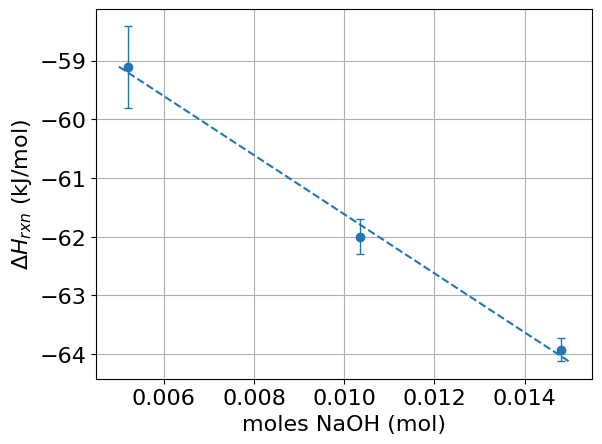

ΔH (neut):  -56.6 ± 0.8 kJ/mol
Exp ΔH:  -57.3 kJ/mol
Exp ΔH:  -57.9 kJ/mol


In [ ]:
# Create the plot here
molNaOH=[0.005209283653846152, 0.010340740384615384, 0.014806572115384614]
deltaH=[-59.11065998,-61.99949214,-63.92224623]

best_fit_neut= scipy.stats.linregress(molNaOH,deltaH)

# Plot the original data
plt.plot(molNaOH,deltaH,'o')
plt.errorbar(molNaOH,deltaH,yerr=[0.7,0.3,0.2],xerr=[5e-6,5e-6,5e-6],linestyle='none',color='C0',elinewidth=1,capsize=3)
# Plot the best fit parameters
best_fit_neut.slope*np.array([0.005,0.010,0.015])+best_fit_neut.intercept
plt.plot(np.array([0.005,0.010,0.015]),best_fit_neut.slope*np.array([0.005,0.010,0.015])+best_fit_neut.intercept,'C0--')

plt.xlabel(r'moles NaOH (mol)')
plt.ylabel(r'$\Delta H_{rxn}$ (kJ/mol)')
plt.grid(True)
plt.show()

print('ΔH (neut): ',best_fit_neut.intercept.round(1),'±', 2*best_fit_neut.intercept_stderr.round(1),'kJ/mol')

#There are two reported experimental values for the heat of neutralization
print('Exp ΔH: ',str(-57.3),'kJ/mol')
print('Exp ΔH: ',str(-57.9),'kJ/mol')

In [ ]:
print('ΔH (neut): ',(best_fit_neut.intercept/4.184).round(1),'±', (2*best_fit_neut.intercept_stderr/4.184).round(1),'kcal/mol')

#There are two reported experimental values for the heat of neutralization
print('Exp ΔH: ',str(-13.7),'kcal/mol')
print('Exp ΔH: ',str(-13.8),'kcal/mol')

ΔH (neut):  -13.5 ± 0.2 kcal/mol
Exp ΔH:  -13.7 kcal/mol
Exp ΔH:  -13.8 kcal/mol


In [ ]:
# @title Key Points
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.green-note {
    color: #155724; /* Dark green for text */
    background-color: #d4edda; /* Light green background */
    border-left: 5px solid #28a745; /* Bright green border */
    padding: 0.5em;
    font-size: 1.25em; /* Consistent with text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean and modern font */
}
div.green-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.green-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="green-note">
    <strong>Key Points:</strong>
    <ul>
        <li>Import your Excel data with the <code>pd.read_excel()</code></li>
        <li>Perform linear and nonlinear regression fitting on experimental thermograms</li>
        <li>Utilize Python functions to automate repetitive tasks</li>
        <li>Perform numerical integration on experimental thermograms</li>
        <li>Visualize and interpret manual and computed optimization procedures</li>
        <li>Calculate \(\Delta H_{rxn}\) by calculating \(\Delta T\) from a thermogram</li>
    </ul>
</div>